Here you can find problem b (with some extensions) and e.

## Problem b)
In this problem we first find the percentages for false positives and negatives as well as true positives and negatives in the COMPAS predictions. After this, we  at the rate of recidivism given a medium-high COMPAS score (decile_score >= 5) and look at the variations for different attributes (ethnicity, sex).

Missing: Discussion of final results

In [1192]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Read data from csv-file and print headers
data = pd.read_csv('compas-scores-two-years.csv')

data.keys()

Index(['id', 'name', 'first', 'last', 'compas_screening_date', 'sex', 'dob',
       'age', 'age_cat', 'race', 'juv_fel_count', 'decile_score',
       'juv_misd_count', 'juv_other_count', 'priors_count',
       'days_b_screening_arrest', 'c_jail_in', 'c_jail_out', 'c_case_number',
       'c_offense_date', 'c_arrest_date', 'c_days_from_compas',
       'c_charge_degree', 'c_charge_desc', 'is_recid', 'r_case_number',
       'r_charge_degree', 'r_days_from_arrest', 'r_offense_date',
       'r_charge_desc', 'r_jail_in', 'r_jail_out', 'violent_recid',
       'is_violent_recid', 'vr_case_number', 'vr_charge_degree',
       'vr_offense_date', 'vr_charge_desc', 'type_of_assessment',
       'decile_score.1', 'score_text', 'screening_date',
       'v_type_of_assessment', 'v_decile_score', 'v_score_text',
       'v_screening_date', 'in_custody', 'out_custody', 'priors_count.1',
       'start', 'end', 'event', 'two_year_recid'],
      dtype='object')

In [1193]:
# We demand that the crime was committed within 30 days of COMPAS Screening for data quality:

data = data[(data["days_b_screening_arrest"] <= 30) & (data["days_b_screening_arrest"] >= -30)]

# Extracting relevant columns:
data = data[['sex', 'age', 'race', 'decile_score', 'score_text', 'is_violent_recid', 'v_score_text','two_year_recid']]
# 'is_violent_recid' together with 'two_year_recid' can be used to find the violent recids within the 2 year period.

In [1194]:
# Create filters
false_pos = (data['decile_score'] > 4) & (data['two_year_recid'] == 0)
false_neg = (data['decile_score'] <= 4) & (data['two_year_recid'] == 1)

true_pos = (data['decile_score'] > 4) & (data['two_year_recid'] == 1)
true_neg = (data['decile_score'] <= 4) & (data['two_year_recid'] == 0)

"""# Equally, for violent recidivism

false_pos_v = (data['decile_score'] > 4) & (data['two_year_recid'] == 0)
false_neg_v = (data['decile_score'] <= 4) & (data['two_year_recid'] == 1)

true_pos_v = (data['decile_score'] > 4) & (data['two_year_recid'] == 1)
true_neg_v = (data['decile_score'] <= 4) & (data['two_year_recid'] == 0)"""

"# Equally, for violent recidivism\n\nfalse_pos_v = (data['decile_score'] > 4) & (data['two_year_recid'] == 0)\nfalse_neg_v = (data['decile_score'] <= 4) & (data['two_year_recid'] == 1)\n\ntrue_pos_v = (data['decile_score'] > 4) & (data['two_year_recid'] == 1)\ntrue_neg_v = (data['decile_score'] <= 4) & (data['two_year_recid'] == 0)"

In [1195]:
print(f'Rate of false positives: {round(100*len(data[false_pos])/len(data), 1)}%')
print(f'Rate of false negatives: {round(100*len(data[false_neg])/len(data), 1)}%')
print(f'Rate of true positives: {round(100*len(data[true_pos])/len(data), 1)}%')
print(f'Rate of true negatives: {round(100*len(data[true_neg])/len(data), 1)}%')

Rate of false positives: 16.5%
Rate of false negatives: 17.4%
Rate of true positives: 28.1%
Rate of true negatives: 38.0%


In [1196]:
all = (data['sex'] == data['sex']) #this is the same as no filter
male = (data['sex'] == 'Male')
female = (data['sex'] == 'Female')
cauca = (data['race'] == 'Caucasian')
afro = (data['race'] == 'African-American')



filters = [(all, 'all'), (male, 'male'), (female, 'female'), (cauca, 'Caucasian'), (afro, 'African-American')]

recid = (data['two_year_recid'] == 1)

for filter, name in filters:
    print(f'Rate of false positives, {name} ({len(data[false_pos & filter])}): {round(100*len(data[false_pos & filter])/len(data[filter]), 1)}%')
    print(f'Rate of false negatives, {name} ({len(data[false_neg & filter])}): {round(100*len(data[false_neg & filter])/len(data[filter]), 1)}%')
    print(f'Rate of true positives, {name} ({len(data[true_pos & filter])}): {round(100*len(data[true_pos & filter])/len(data[filter]), 1)}%')
    print(f'Rate of true negatives, {name} ({len(data[true_neg & filter])}): {round(100*len(data[true_neg & filter])/len(data[filter]), 1)}%')
    print()

Rate of false positives, all (1018): 16.5%
Rate of false negatives, all (1076): 17.4%
Rate of true positives, all (1733): 28.1%
Rate of true negatives, all (2345): 38.0%

Rate of false positives, male (788): 15.8%
Rate of false negatives, male (909): 18.2%
Rate of true positives, male (1487): 29.8%
Rate of true negatives, male (1813): 36.3%

Rate of false positives, female (230): 19.6%
Rate of false negatives, female (167): 14.2%
Rate of true positives, female (246): 20.9%
Rate of true negatives, female (532): 45.3%

Rate of false positives, Caucasian (282): 13.4%
Rate of false negatives, Caucasian (408): 19.4%
Rate of true positives, Caucasian (414): 19.7%
Rate of true negatives, Caucasian (999): 47.5%

Rate of false positives, African-American (641): 20.2%
Rate of false negatives, African-American (473): 14.9%
Rate of true positives, African-American (1188): 37.4%
Rate of true negatives, African-American (873): 27.5%



These calculations tell us that the likelihood of receiving a false positive is higher if you're African-American than if you are Caucasian, and also if you're female rather than male. The model simultaneously gives Caucasian defendants a higher chance of false negatives than African-American defendants. The same favor is shown for males and females respectively.

In other words, the model exhibits two types of injustices that both are 'benefit' Caucasian individuals and males. You are more likely to be mistakenly punished if you're African-American and if you're female, while Caucasian individuals and males are more likely to mistakenly receive a low score, which promotes pretrial release and parole.

We now want to find the rate of recidivism given that the assigned COMPAS score is 'high' (which in the dataset corresponds to medium-high in 'score_text', or a decile value of 5 or above). This can be written as $P(recid|high)$. We firstly do this for the entire dataset without filtering for characteristics. This value is found by looking at the number of true positives divided by the number of positives (positive = high).

In [1197]:
high = (data['decile_score'] > 4)
print(f'Rate of recidivism, given high COMPAS score: {round(100*len(data[true_pos])/len(data[high]), 1)}%')

Rate of recidivism, given high COMPAS score: 63.0%


Rate of recidivism, all: 45.5%
Rate of recidivism, male: 47.9%
Rate of recidivism, female: 35.1%
Rate of recidivism, Caucasian: 39.1%
Rate of recidivism, African-American: 52.3%


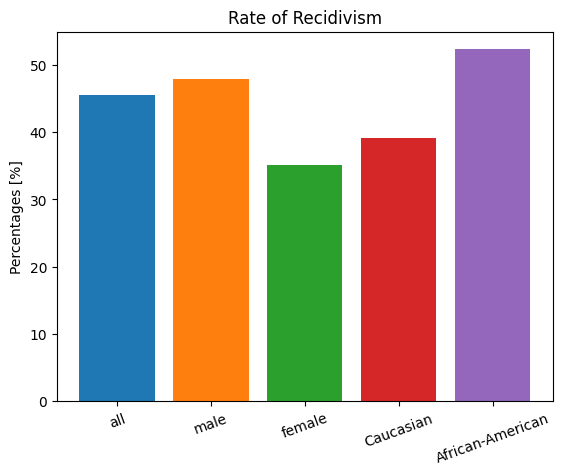


Rate of recidivism, high COMPAS score, all: 63.0%
Rate of recidivism, high COMPAS score, male: 65.4%
Rate of recidivism, high COMPAS score, female: 51.7%
Rate of recidivism, high COMPAS score, Caucasian: 59.5%
Rate of recidivism, high COMPAS score, African-American: 65.0%


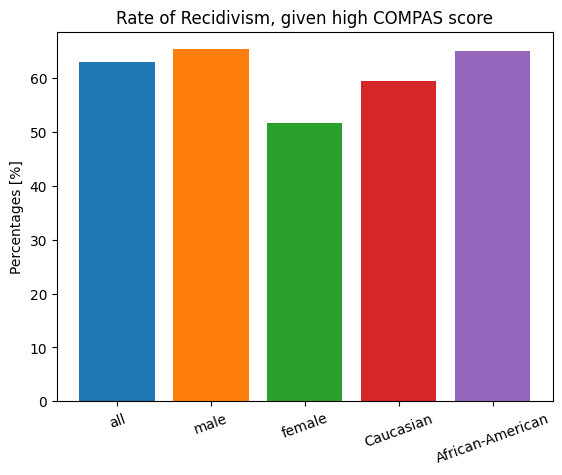

In [1198]:
for filter, name in filters:
    print(f'Rate of recidivism, {name}: {round(100*len(data[recid & filter])/len(data[filter]), 1)}%')
    plt.bar(name, 100*len(data[recid & filter])/len(data[filter]))
plt.title("Rate of Recidivism")
plt.ylabel("Percentages [%]")
plt.xticks(rotation=20)
plt.show()

print()
for filter, name in filters:
    print(f'Rate of recidivism, high COMPAS score, {name}: {round(100*len(data[true_pos & filter])/len(data[high & filter]), 1)}%')
    plt.bar(name, 100*len(data[true_pos & filter])/len(data[high & filter]))
plt.title("Rate of Recidivism, given high COMPAS score")
plt.ylabel("Percentages [%]")
plt.xticks(rotation=20)
plt.show()

Rate of recidivism, All males: 47.9%
Rate of recidivism, Caucasian males: 40.2%
Rate of recidivism, African-American males: 55.5%
Rate of recidivism, All females: 35.1%
Rate of recidivism, Caucasian females: 35.3%
Rate of recidivism, African-American females: 37.0%


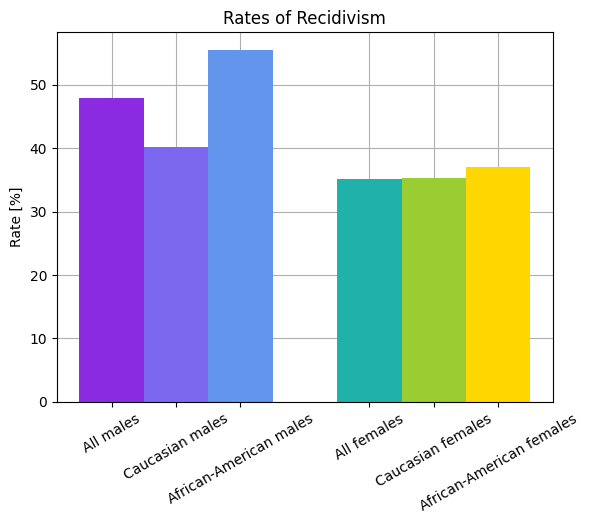

Rate of recidivism, All males: 65.4%
Rate of recidivism, Caucasian males: 62.5%
Rate of recidivism, African-American males: 67.2%
Rate of recidivism, All females: 51.7%
Rate of recidivism, Caucasian females: 51.1%
Rate of recidivism, African-American females: 51.8%


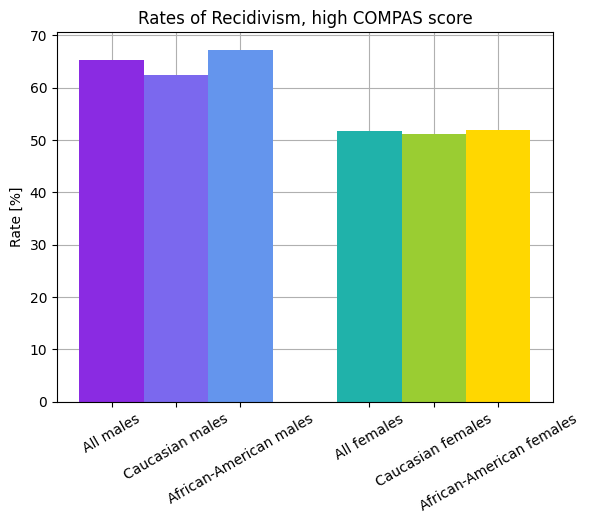

In [1199]:
width = 1
race = [(all, 'All', -width, ("blueviolet", "lightseagreen")), (cauca, 'Caucasian', 0, ("mediumslateblue", "yellowgreen")), (afro, 'African-American', width, ("cornflowerblue", "gold"))]
sex = [(male, 'males', -1.5*width, 0), (female, 'females', 1.5*width, 1)]

xrlist = np.array([rname for (r, rname, posr, cr) in race])
xsexlist = np.array([sname for (s, sname, poss, sindex) in sex])
xlist = np.array([xrlist +" "+ xsexlist[i] for i in range(len(xsexlist))]).ravel()


x = []
pos0 = 0
for s, sname, pos, c in sex: # (true_pos & group / high & group)
    for r, rname, posr, cr in race:
        print(f'Rate of recidivism, {rname} {sname}: {round(100*len(data[recid & r & s])/len(data[r & s]), 1)}%')
        plt.bar(pos0+posr+pos, 100*len(data[recid & r & s])/len(data[r & s]), width=width, color=cr[c], zorder=2)
        x.append(pos0+posr+pos)
    pos0 += 1
plt.title("Rates of Recidivism")
plt.ylabel("Rate [%]")
plt.xticks(x, xlist, rotation=30)
plt.grid(zorder=0)
plt.show()


x = []
pos0 = 0
for s, sname, pos, c in sex: # (true_pos & group / high & group)
    for r, rname, posr, cr in race:
        print(f'Rate of recidivism, {rname} {sname}: {round(100*len(data[true_pos & r & s])/len(data[high & r & s]), 1)}%')
        plt.bar(pos0+posr+pos, 100*len(data[true_pos & r & s])/len(data[high & r & s]), width=width, color=cr[c], zorder=2)
        x.append(pos0+posr+pos)
    pos0 += 1
plt.title("Rates of Recidivism, high COMPAS score")
plt.ylabel("Rate [%]")
plt.xticks(x, xlist, rotation=30)
plt.grid(zorder=0)
plt.show()

In the plot for general rates of recidivism we may notice that the bar for all females is lower than both African-American and Caucasian females. The resolution is that female defendants in some of the other race descriptions have lower rates of recidivism than both African-American and Caucasian females.

Rate of recidivism, score: 1, Caucasian males: 20.9%
Rate of recidivism, score: 1, African-American males: 26.0%
Rate of recidivism, score: 1, Caucasian females: 21.9%
Rate of recidivism, score: 1, African-American females: 13.0%

Rate of recidivism, score: 2, Caucasian males: 33.9%
Rate of recidivism, score: 2, African-American males: 35.0%
Rate of recidivism, score: 2, Caucasian females: 20.3%
Rate of recidivism, score: 2, African-American females: 15.0%

Rate of recidivism, score: 3, Caucasian males: 35.2%
Rate of recidivism, score: 3, African-American males: 45.6%
Rate of recidivism, score: 3, Caucasian females: 32.1%
Rate of recidivism, score: 3, African-American females: 27.9%

Rate of recidivism, score: 4, Caucasian males: 41.1%
Rate of recidivism, score: 4, African-American males: 48.6%
Rate of recidivism, score: 4, Caucasian females: 36.6%
Rate of recidivism, score: 4, African-American females: 39.0%

Rate of recidivism, score: 5, Caucasian males: 46.6%
Rate of recidivism, sco

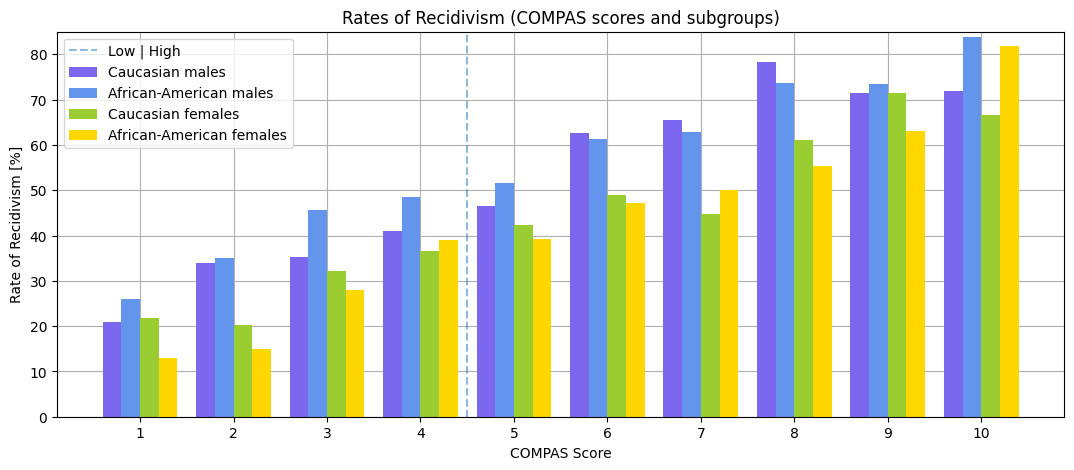

In [1200]:
race_ = [(cauca, 'Caucasian', 0, ("mediumslateblue", "yellowgreen")), (afro, 'African-American', width, ("cornflowerblue", "gold"))]

slist = [((data['decile_score'] == (i+1)), f"{i+1}") for i in range(10)]
scorelist = [s for (s, sname) in slist]

xrlist = np.array([rname for (r, rname, posr, cr) in race_])
xslist = np.array([sname for (s, sname) in slist])
xlist = np.array([xrlist +", "+ xslist[i] for i in range(len(xslist))]).ravel()

# ALL COMPAS SCORES:

pos0 = 0
x=[]
plt.figure(figsize=(13,5))

for score, scname in slist:
    x.append(pos0+1.5*width)
    for s, sname, pos, c in sex: # (true_pos & group / high & group)
        for r, rname, posr, cr in race_:
            print(f'Rate of recidivism, score: {scname}, {rname} {sname}: {round(100*len(data[score & recid & r & s])/len(data[score & r & s]), 1)}%')
            if pos0 <= 2*width*len(race_):
                plt.bar(pos0+posr, 100*len(data[score & recid & r & s])/len(data[score & r & s]), width=width, color=cr[c], zorder=2, label=str(f"{rname} {sname}"))
            else:
                plt.bar(pos0+posr, 100*len(data[score & recid & r & s])/len(data[score & r & s]), width=width, color=cr[c], zorder=2)
        pos0 += 2*width
    pos0 += width
    print()

plt.title(f"Rates of Recidivism (COMPAS scores and subgroups)")
plt.ylabel("Rate of Recidivism [%]")
plt.xlabel("COMPAS Score")
plt.grid(zorder=0)
plt.xticks(x, xslist)
plt.vlines(x[3]+2.5*width, -10, 100, label='Low | High', linestyle='--', alpha=0.5)
plt.ylim(0, 85)
plt.legend()
plt.show()

We see that males have a higher rate of being prosecuted for recidivism than females, and also that African-Americans share the same relation to Caucasians.

These results suggest that females given a high recidivism score have a lower rate of recidivism than males sharing the same scores. It could be the case that the 'high-risk females' all have decile scores on the low-end (e.g. 5-6) while the males are on the higher end (e.g. 7-9), however, the average scores of high-risk males and high-risk females are the same as we can see in the output below, both sexes with an average of 7. In the final plot we see that defendants rated a COMPAS decile score of 10, i.e. the maximum risk score possible, the differences between females and males have decreased, while the differences between Caucasians and African-Americans persists.

A perfectly unbiased model would have equal rates across the different attributes for every decile score, i.e. equal heights across the corresponding bars, (and for a perfect model these would be 100% for a decile score of 10, and, 0% for a decile score of 1, assuming it is the lowest possible score). Can a model achieving such a distribution still be unfair?

Looking at Caucasian males scoring 8, the rate of recidivism is strikingly higher than the others in the same category, and noticably lower than the rates at both 9 and 10. An interpretation of this is that a portion of the recidivising Caucasian males at score 8 _should have_ been allocated a higher score. Doing so would decrease the rate of recidivism at this score and increased the rates at 9 and 10. In other words, it could be that the model is too forgiving to Caucasian males at the high-end of scores.

This plot also suggests that COMPAS is relatively too kind to African-American males 

The differences in heights show an unfairness in the model. The percentage of false positives for females compared to males makes it unfair to females.

In [1201]:
high_fem = data[(data['decile_score'] > 4) & (data['sex'] == 'Female')]
avr_high_fem = np.sum(np.array(high_fem['decile_score']))/len(high_fem)

high_male = data[(data['decile_score'] > 4) & (data['sex'] == 'Male')]
avr_high_male = np.sum(np.array(high_male['decile_score']))/len(high_male)

print(f"Average COMPAS score for 'high-risk females': {round(avr_high_fem,0)}")
print(f"Average COMPAS score for 'high-risk males': {round(avr_high_male,0)}")

Average COMPAS score for 'high-risk females': 7.0
Average COMPAS score for 'high-risk males': 7.0


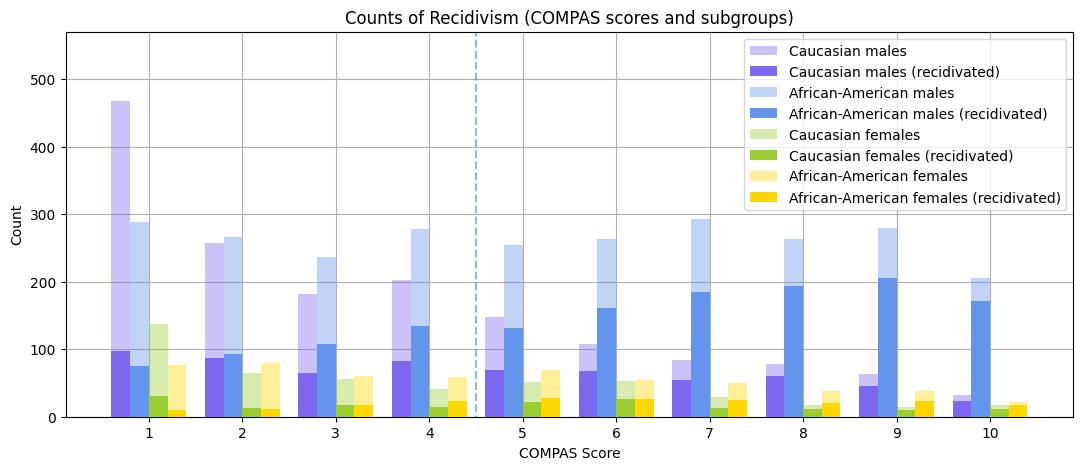

In [1202]:
# ALL COMPAS SCORES:

pos0 = 0
x=[]
plt.figure(figsize=(13,5))

for score, scname in slist:
    x.append(pos0+1.5*width)
    for s, sname, pos, c in sex: # (true_pos & group / high & group)
        for r, rname, posr, cr in race_:
            if pos0 <= 2*width*len(race_):
                plt.bar(pos0+posr, len(data[score & r & s]), width=width, color=cr[c], alpha=0.4, zorder=2, label=str(f"{rname} {sname}"))
                plt.bar(pos0+posr, len(data[score & recid & r & s]), width=width, color=cr[c], zorder=3, label=str(f"{rname} {sname} (recidivated)"))
            else:
                plt.bar(pos0+posr, len(data[score & r & s]), width=width, color=cr[c], alpha=0.4, zorder=2)
                plt.bar(pos0+posr, len(data[score & recid & r & s]), width=width, color=cr[c], zorder=3)
        pos0 += 2*width
    pos0 += width

plt.title(f"Counts of Recidivism (COMPAS scores and subgroups)")
plt.ylabel("Count")
plt.xlabel("COMPAS Score")
plt.grid(zorder=0)
plt.xticks(x, xslist)
plt.vlines(x[3]+2.5*width, -10, 1000, linestyle='--', alpha=0.5)
plt.ylim(0, 570)
plt.legend(loc="upper right")
plt.show()

This plot shows the counts for each score together with the corresponding counts of recidivism. I didn't learn anything special from this, but you may decide for yourself.

Rate of recidivism, All males: 75.4%
Rate of recidivism, Caucasian males: 74.6%
Rate of recidivism, African-American males: 76.4%
Rate of recidivism, All females: 64.9%
Rate of recidivism, Caucasian females: 66.0%
Rate of recidivism, African-American females: 64.3%


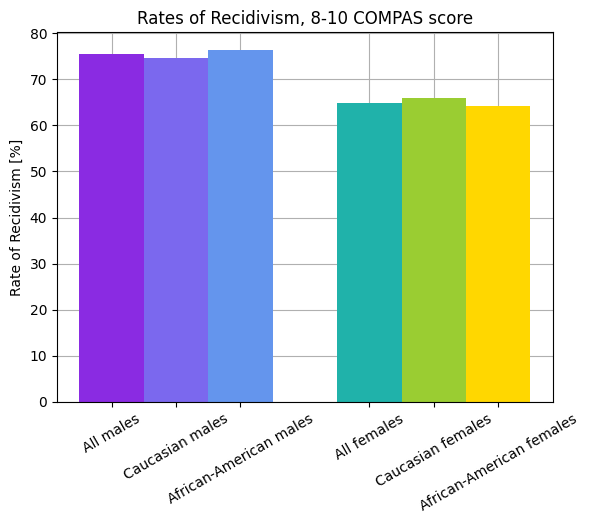

In [1203]:
hiigh = (data['decile_score'] >= 8)

sex = [(male, 'males', -1.5*width, 0), (female, 'females', 1.5*width, 1)]

xrlist = np.array([rname for (r, rname, posr, cr) in race])
xsexlist = np.array([sname for (s, sname, poss, sindex) in sex])
xlist = np.array([xrlist +" "+ xsexlist[i] for i in range(len(xsexlist))]).ravel()

x = []
pos0 = 0
for s, sname, pos, c in sex: # (true_pos & group / high & group)
    for r, rname, posr, cr in race:
        print(f'Rate of recidivism, {rname} {sname}: {round(100*len(data[hiigh & recid & r & s])/len(data[hiigh & r & s]), 1)}%')
        plt.bar(pos0+posr+pos, 100*len(data[hiigh & recid & r & s])/len(data[hiigh & r & s]), width=width, color=cr[c], zorder=2)
        x.append(pos0+posr+pos)
    pos0 += 1
plt.title("Rates of Recidivism, 8-10 COMPAS score")
plt.ylabel("Rate of Recidivism [%]")
plt.xticks(x, xlist, rotation=30)
plt.grid(zorder=0)
plt.show()

Here it looks as though a COMPAS score of 8-10 holds potential as a predictive value (>70%), while being quite fair. This is, in fact, the decile scores that the Northpointe labels 'high', as opposed to ProPublica's 5-10 range. Furthermore, Northpointe has created a seperate model for females to combat the injustice we see at these decile scores. We can take a look into the other race categories.

But first, we return to false positives and negatives at this score range. We also impose a negative to mean a score at 1. We find:
<br><br>

In [1204]:
false_pos = (data['decile_score'] >= 8) & (data['two_year_recid'] == 0)
false_neg = (data['decile_score'] == 1) & (data['two_year_recid'] == 1)
true_pos = (data['decile_score'] >= 8) & (data['two_year_recid'] == 1)
true_neg = (data['decile_score'] == 1) & (data['two_year_recid'] == 0)

"""
for filter, name in filters:
    if len(data[filter & male & (data['decile_score'] == 1)])+len(data[filter & male & hiigh]) != 0:
        FP = round(100*len(data[false_pos & male & filter])/(len(data[filter & male & (data['decile_score'] == 1)])+len(data[filter & male & hiigh])), 1)
        FN = round(100*len(data[false_neg & male & filter])/(len(data[filter & male & (data['decile_score'] == 1)])+len(data[filter & male & hiigh])), 1)
        TP = round(100*len(data[true_pos & male & filter])/(len(data[filter & male & (data['decile_score'] == 1)])+len(data[filter & male & hiigh])), 1)
        TN = round(100*len(data[true_neg & male & filter])/(len(data[filter & male & (data['decile_score'] == 1)])+len(data[filter & male & hiigh])), 1)
    print(f'Rate of false positives, {name} male ({len(data[false_pos & filter])}): {FP}%')
    print(f'Rate of false negatives, {name} male ({len(data[false_neg & filter])}): {FN}%')
    print(f'Rate of true positives, {name} male ({len(data[true_pos & filter])}): {TP}%')
    print(f'Rate of true negatives, {name} male ({len(data[true_neg & filter])}): {TN}%')
    print()
"""
for filter, name in filters:
    if (len(data[filter & male & (data['decile_score'] == 1)])+len(data[filter & male & hiigh]) != 0) and (name != 'male'):
        FP = round(100*len(data[false_pos & male & filter])/(len(data[filter & male])), 1)
        FN = round(100*len(data[false_neg & male & filter])/(len(data[filter & male])), 1)
        TP = round(100*len(data[true_pos & male & filter])/(len(data[filter & male])), 1)
        TN = round(100*len(data[true_neg & male & filter])/(len(data[filter & male])), 1)
        inconclusive =round(100*len(data[male & filter & (data['decile_score'] >= 2) & ~hiigh])/len(data[male & filter]), 1)
        print(f'Rate of false positives, {name} male ({len(data[false_pos & filter])}): {FP}%')
        print(f'Rate of false negatives, {name} male ({len(data[false_neg & filter])}): {FN}%')
        print(f'Rate of true positives, {name} male ({len(data[true_pos & filter])}): {TP}%')
        print(f'Rate of true negatives, {name} male ({len(data[true_neg & filter])}): {TN}%')
        print(f'Rate of inconclusive results (scores 2-7), {name} male ({len(data[male & filter & (data['decile_score'] > 1) & ~hiigh])}): {inconclusive}%')
        print()


"""
for filter, name in filters:
    print(f'Rate of false positives, {name} ({len(data[false_pos & filter])}): {round(100*len(data[false_pos & filter])/len(data[filter]), 1)}%')
    print(f'Rate of false negatives, {name} ({len(data[false_neg & filter])}): {round(100*len(data[false_neg & filter])/len(data[filter]), 1)}%')
    #print(f'Rate of true positives, {name} ({len(data[true_pos & filter])}): {round(100*len(data[true_pos & filter])/len(data[filter]), 1)}%')
    #print(f'Rate of true negatives, {name} ({len(data[true_neg & filter])}): {round(100*len(data[true_neg & filter])/len(data[filter]), 1)}%')
    print()"""
"""
print(f"Rate of false positives for African-American individuals over Caucasian individuals: x{round((len(data[false_pos & male & afro])/(len(data[afro & male & (data['decile_score'] == 1)])+len(data[afro & hiigh & male])))/(len(data[false_pos & cauca])/(len(data[cauca & (data['decile_score'] == 1)])+len(data[cauca & hiigh]))), 1)}")
print(f"Rate of false negatives for Caucasian individuals over African-American individuals: x{round((len(data[false_neg & male & cauca])/(len(data[cauca & male & (data['decile_score'] == 1)])+len(data[cauca & hiigh & male])))/(len(data[false_neg & afro])/(len(data[afro & (data['decile_score'] == 1)])+len(data[afro & hiigh]))), 1)}")
print()"""

print(f"Rate of false positives for African-American males over Caucasian males: x{round((len(data[false_pos & male & afro])/len(data[afro & male]))/(len(data[false_pos & male & cauca])/len(data[cauca & male])), 1)}")
print(f"Rate of false negatives for Caucasian males over African-American males: x{round((len(data[false_neg & male & cauca])/len(data[cauca & male]))/(len(data[false_neg & male & afro])/len(data[afro & male])), 1)}")
#Approximately same probability difference whether each group is divided by their whole race category or by the members within scores 1 & 8-10.
print()
print(f"Rate of false positives for African-American males over Caucasian males, will not recid: x{round((len(data[false_pos & male & afro])/len(data[afro & male & ~recid]))/(len(data[false_pos & male & cauca])/len(data[cauca & male & ~recid])), 1)}")
print(f"Rate of false negatives for Caucasian males over African-American males, will recid: x{round((len(data[false_neg & male & cauca])/len(data[cauca & male & recid]))/(len(data[false_neg & male & afro])/len(data[afro & male & recid])), 1)}")

Rate of false positives, all male (297): 4.9%
Rate of false negatives, all male (277): 4.6%
Rate of true positives, all male (847): 15.0%
Rate of true negatives, all male (1009): 15.9%
Rate of inconclusive results (scores 2-7), all male (2979): 59.6%

Rate of false positives, Caucasian male (61): 2.7%
Rate of false negatives, Caucasian male (128): 6.0%
Rate of true positives, Caucasian male (162): 8.0%
Rate of true negatives, Caucasian male (477): 22.8%
Rate of inconclusive results (scores 2-7), Caucasian male (980): 60.5%

Rate of false positives, African-American male (211): 6.7%
Rate of false negatives, African-American male (85): 2.9%
Rate of true positives, African-American male (634): 21.7%
Rate of true negatives, African-American male (280): 8.1%
Rate of inconclusive results (scores 2-7), African-American male (1591): 60.6%

Rate of false positives for African-American males over Caucasian males: x2.5
Rate of false negatives for Caucasian males over African-American males: x2.1


If we compare the unfairness found in the rates of recidivism and the unfairness found in false positives (FP) and false negatives (FN), we see that the former is unfair against Caucasians and the latter is unfair against African-Americans. This is because we are working with two (even three) different notions of fairness.

For rates of recidivism, we are saying that the fair outcome would be equal rates at equal scores, which is a reasonable notion. Two groups with the same scores should have the same rate of recidivism (assuming the populations are large).
Meanwhile, the rate of FP and FN is contingent on the total rate of defendants that recidivate in a group. The percentage of false positives can be thought of as follows; If we pick a random individual from the group of Caucasian males, the likelihood that he has been assigned a high score _and_ recidivates is 2.7%. If we do the same for the group of African-American males, the likelihood is 6.9%.
This difference in likelihood stems from the fact that there is a higher rate of African-American males who recidivate, and so, this difference in false positives and negatives isn't necessarily unfair.
The issue appears when a new individual is to be judged in accordance with the old data. The likelihood that an African-American defendant who will not recidivate gets assigned a high score (8-10), is 3.3 times as likely as a Caucasian defendant who will not recidivate receiving a high score (8-10).

Count of recidivism, All males: 749
Count of recidivism, Caucasian males: 129
Count of recidivism, African-American males: 571
Count of recidivism, All females: 98
Count of recidivism, Caucasian females: 33
Count of recidivism, African-American females: 63


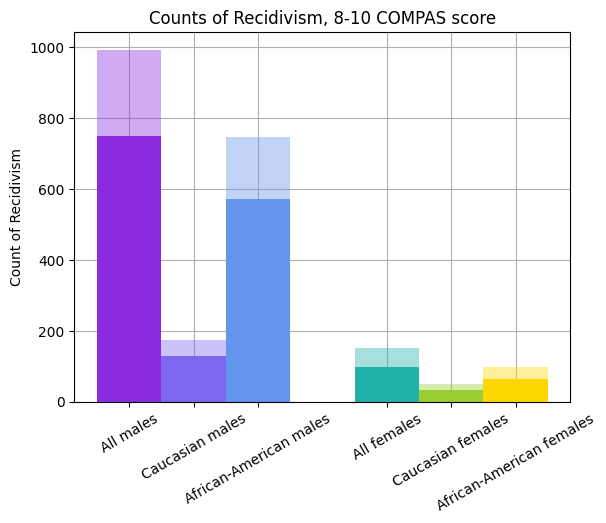

In [1205]:
hiigh = (data['decile_score'] >= 8)

sex = [(male, 'males', -1.5*width, 0), (female, 'females', 1.5*width, 1)]

xrlist = np.array([rname for (r, rname, posr, cr) in race])
xsexlist = np.array([sname for (s, sname, poss, sindex) in sex])
xlist = np.array([xrlist +" "+ xsexlist[i] for i in range(len(xsexlist))]).ravel()

x = []
pos0 = 0
for s, sname, pos, c in sex: # (true_pos & group / high & group)
    for r, rname, posr, cr in race:
        print(f'Count of recidivism, {rname} {sname}: {round(len(data[hiigh & recid & r & s]), 1)}')
        plt.bar(pos0+posr+pos, len(data[hiigh & r & s]), width=width, color=cr[c], alpha=0.4, zorder=2)
        plt.bar(pos0+posr+pos, len(data[hiigh & recid & r & s]), width=width, color=cr[c], zorder=2)
        x.append(pos0+posr+pos)
    pos0 += 1
plt.title("Counts of Recidivism, 8-10 COMPAS score")
plt.ylabel("Count of Recidivism")
plt.xticks(x, xlist, rotation=30)
plt.grid(zorder=0)
plt.show()

<br><br>

Here, a false positive means the individual has received a score of 8-10, and not recidivated. On the other hand, a false negative means they received a score of 1 and did recidivate.

This means that any individual has a 4.5% chance of being assigned a score of 1 and recidivating. and slightly more likely of being assigned a score of 8-10 and not recidivating.
If one is a male, there is a 4.9% chance of scoring 8-10 and not recidivating, and a 4.6% chance of scoring 1 and recidivating. 

As opposed to previously, the scores do not obviously benefit males over females, though the results for females are better (cleaner), meaning you are less likely of your score being false if you're female (which may be seen as a benefit).

Looking at Caucasian and African-American defendants, it does not look as promising. African-American individuals are 2.3 times as likely to receive a false positive as compared to Caucasian individuals, and Caucasian individuals are 2.3 times as likely to receive a false negative as compared to African-American individuals, which indeed sounds like an outrageously unfair difference.

<br><br>
Now, for a quick analysis of the unfairness toward hispanics:

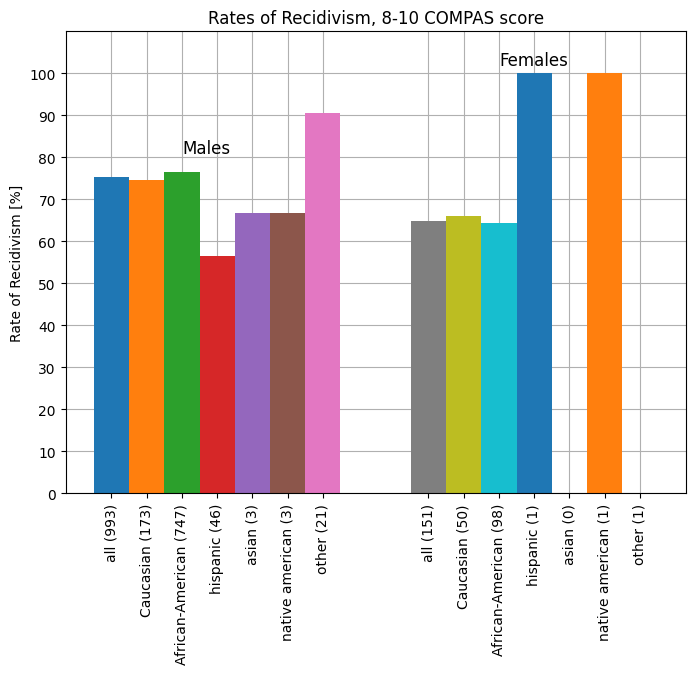

In [1206]:
hiigh = (data['decile_score'] >= 8)

hispanic = (data['race'] == 'Hispanic')
asian = (data['race'] == 'Asian')
natam = (data['race'] == 'Native American')
other = (data['race'] == 'Other')

races = [(all, 'all', 0, ("blueviolet", "lightseagreen")), 
         (cauca, 'Caucasian', width, ("mediumslateblue", "yellowgreen")), 
         (afro, 'African-American', 2*width, ("cornflowerblue", "gold")), 
         (hispanic, 'hispanic', 3*width, ("cornflowerblue", "gold")), 
         (asian, 'asian', 4*width, ("cornflowerblue", "gold")), 
         (natam, 'native american', 5*width, ("cornflowerblue", "gold")), 
         (other, 'other', 6*width, ("cornflowerblue", "gold"))] # all races

sex = [(male, 'males', -4*width, 0), (female, 'females', 4*width, 1)]


xlist = np.array([rname+str(f' ({len(data[hiigh & r & s])})') for (s, sname, poss, sindex) in sexs for (r, rname, posr, cr) in races]) # race (number)


x = []
pos0 = 0
plt.figure(figsize=(8,6))
for s, sname, pos, c in sex: # (true_pos & group / high & group)
    for r, rname, posr, cr in races:
        if len(data[hiigh & r & s]) == 0:
            #print(f'Rate of recidivism, score 8-10, {rname} {sname}: 0%')
            plt.bar(pos0+posr+pos, 0, width=width, color=cr[c], zorder=2)
        else:
            #print(f'Rate of recidivism, score 8-10, {rname} {sname}: {round(100*len(data[hiigh & recid & r & s])/len(data[hiigh & r & s]), 1)}%') ## UNCHECK TO PRINT NUMBER VALUES :)
            plt.bar(pos0+posr+pos, 100*len(data[hiigh & recid & r & s])/len(data[hiigh & r & s]), width=width, zorder=2)
            #plt.text(pos0+posr+pos-width/4, 100*len(data[hiigh & recid & r & s])/len(data[hiigh & r & s])+2, f'{nr}')
        x.append(pos0+posr+pos)
    pos0 += width
plt.title("Rates of Recidivism, 8-10 COMPAS score")
plt.ylabel("Rate of Recidivism [%]")
#plt.vlines(x, 0, 120, linestyle='--', color='teal', alpha=0.5, zorder=0)
plt.ylim(0, 110)
plt.xticks(x, xlist, rotation=90)
plt.yticks(np.arange(0,101, 10))
plt.text(2*width - 4*width, 81, 'Males', fontsize=12)
plt.text(3*width + 4*width, 102, 'Females', fontsize=12)
plt.grid(zorder=0)
plt.show()

<br><br><br><br>
The lack of data for the other racecategories leaves us without sufficient ground for any conclusion. The column for hispanic males is indicative of a greater injustice than we have previously seen.  The column for other males is promising, if anything, for the 8-10 scores. The other columns cannot indicate anything about the 8-10 score predictability.
<br><br><br><br>

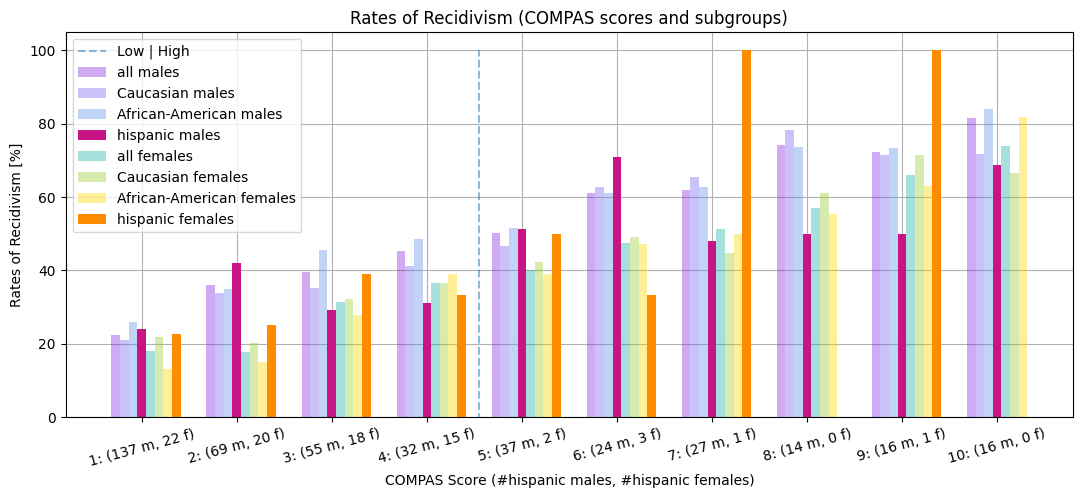

In [1207]:
a = 0.4
race_ = [(all, 'all', 0, ("blueviolet", "lightseagreen"), a), 
         (cauca, 'Caucasian', 1*width, ("mediumslateblue", "yellowgreen"), a), 
         (afro, 'African-American', 2*width, ("cornflowerblue", "gold"), a), 
         (hispanic, 'hispanic', 3*width, ("mediumvioletred", "darkorange"), 1)]

sex = [(male, 'males', 0), (female, 'females', 1)]

slist = [((data['decile_score'] == (i+1)), f"{i+1}") for i in range(10)]
scorelist = [s for (s, sname) in slist]

xrlist = np.array([rname for (r, rname, posr, cr, a) in race_])
xslist = np.array([sname for (s, sname) in slist])
xlist = np.array([xrlist +", "+ xslist[i] for i in range(len(xslist))]).ravel()

xhlist = [str(f'{sname}: ({len(data[score & hispanic & male])} m, {len(data[score & hispanic & female])} f)') for (score, sname) in slist]

# ALL COMPAS SCORES:

pos0 = 0
x=[]
plt.figure(figsize=(13,5))

for score, scname in slist:
    x.append(pos0+3*width)
    for s, sname, c in sex: # (true_pos & group / high & group)
        for r, rname, posr, cr, a in race_:
            if len(data[score & r & s]) == 0:
                #print(f'Rate of recidivism, score: {scname}, {rname} {sname}: 0%')
                print()
            else:
                #print(f'Rate of recidivism, score: {scname}, {rname} {sname}: {round(100*len(data[score & recid & r & s])/len(data[score & r & s]), 1)}%')
                if pos0 <= 2*width*len(race_):
                    plt.bar(pos0+posr, 100*len(data[score & recid & r & s])/len(data[score & r & s]), width=width, color=cr[c], zorder=2, label=str(f"{rname} {sname}"), alpha=a)
                else:
                    plt.bar(pos0+posr, 100*len(data[score & recid & r & s])/len(data[score & r & s]), width=width, color=cr[c], zorder=2, alpha=a)
        pos0 += 4*width
    pos0 += 3*width

plt.title(f"Rates of Recidivism (COMPAS scores and subgroups)")
plt.ylabel("Rates of Recidivism [%]")
plt.xlabel("COMPAS Score (#hispanic males, #hispanic females)")
plt.grid(zorder=0)
plt.xticks(x, xhlist, rotation=15)
plt.vlines(x[3]+6*width, -10, 100, label='Low | High', linestyle='--', alpha=0.5)
plt.ylim(0, 105)
plt.legend()
plt.show()



The behavior of the scores for hispanics shows a more volatile behavior, likely because of the fewer number of agents considered. The high-scoring females will be neglected considering their 0-3 count range. The high-scoring males show a lower recidivism rate than their 'score-family', all the while not receiving any particular bias in the low scores. This does suggest that the model is unfairly strict toward hispanics, however, as a result of the low counts, we are unable to draw any definitive conclusions.

<br>

## Problem e)
In this problem we look at what happens when we create a random forest model that doesn't utilize ethnicity as a variable. In the end, we see that even this model becomes racially biased against afros and to the benefit of Caucasian individuals, suggesting that the data itself (the criminal charges) are racially unjust.

To create a random forest, we have to randomly split the available data into a training set and a test set. The former is used to create the model and the latter to verify its accuracy.

We begin by quantifying the string columns we are to use, namely the columns for sex and charge degree.

<br><br><br><br>

In [1208]:
data = pd.read_csv('compas-scores-two-years.csv')
data = data[(data["days_b_screening_arrest"] <= 30) & (data["days_b_screening_arrest"] >= -30)]
filter = data['sex'] == 'Female'

data.loc[~filter, 'sex'] = 0.0 #males
data.loc[filter, 'sex'] = 1.0 #females

filter = data['c_charge_degree'] == 'F'
data.loc[filter, 'c_charge_degree'] = 1.0 # Felony

filter = data['c_charge_degree'] == 'M'
data.loc[filter, 'c_charge_degree'] = 0.0 # Misdemeanor

data['priors_count'] = np.array(data['priors_count'], dtype=float) #converting integers to floats for the final Partial Dependence plot
data['age'] = np.array(data['age'], dtype=float) #converting integers to floats for the final Partial Dependence plot

data[['age','sex','priors_count','c_charge_degree']] #

,age,sex,priors_count,c_charge_degree
0,69.0,0.0,0.0,1.0
1,34.0,0.0,0.0,1.0
2,24.0,0.0,4.0,1.0
5,44.0,0.0,0.0,0.0
6,41.0,0.0,14.0,1.0
...,...,...,...,...
7209,23.0,0.0,0.0,1.0
7210,23.0,0.0,0.0,1.0
7211,57.0,0.0,0.0,1.0
7212,33.0,1.0,3.0,0.0


<br>
Since the forests will have a varying degree of predictive accuracy, we make 50 forests to estimate the average accuracy. <br><br>
_Note: By a number of manual iterations it looks as though n_estimators above 100 does not significantly impact the accuracy of the forest._
<br><br>

In [1209]:
from sklearn.model_selection import train_test_split
# Random forest:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

N = 50 # number of iterations

X = data[['age','sex','priors_count','c_charge_degree']] # Used variables in model
Y = data['two_year_recid'] # 'Prediction variable'

# Splitting into train and test sets:
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.5) #with test_size = 0.5, we get equally large sets

tot_acc = 0
tot_prec = 0
tot_rec = 0
tot_cm = 0
for i in range(N):
    forest = RandomForestClassifier(n_estimators = 100, max_features='sqrt')
    forest.fit(x_train, y_train)

    pred = forest.predict(x_test)
    acc = accuracy_score(y_test, pred)
    prec = precision_score(y_test, pred)
    rec = recall_score(y_test, pred)
    cm = confusion_matrix(y_test, pred)

    tot_acc += acc
    tot_prec += prec
    tot_rec += rec
    tot_cm += cm

"""print(f"Average accuracy of {N} forests: {round(100*tot_acc/N,1)} %")
print(f"Average precision of {N} forests: {round(100*tot_prec/N,1)} %")
print(f"Average recall of {N} forests: {round(100*tot_rec/N,1)} %")
print()"""
print(f"Average confusion matrix values of {N} forests:")
print(f"True positives: {round(100*tot_cm[1][1]/N/len(x_test), 1)} %")
print(f"True negatives: {round(100*tot_cm[0][0]/N/len(x_test), 1)} %")
print(f"False positives: {round(100*tot_cm[0][1]/N/len(x_test), 1)} %")
print(f"False negatives: {round(100*tot_cm[1][0]/N/len(x_test), 1)} %")

Average confusion matrix values of 50 forests:
True positives: 26.1 %
True negatives: 36.9 %
False positives: 17.8 %
False negatives: 19.3 %


From here on we use the forest created in the final iteration of the loop. As we can see from comparing its behavior to that of the average, it is a fairly representable candidate of the average.
<br><br>

In [1210]:
"""print(f"Accuracy of final forest: {round(100*acc,1)} %")
print(f"Precision of final forest: {round(100*prec,1)} %")
print(f"Recall of final forest: {round(100*rec,1)} %")
print()"""
print(f"Confusion matrix values of final forest:")
print(f"True positives: {round(100*cm[1][1]/len(x_test), 1)} %")
print(f"True negatives: {round(100*cm[0][0]/len(x_test), 1)} %")
print(f"False positives: {round(100*cm[0][1]/len(x_test), 1)} %")
print(f"False negatives: {round(100*cm[1][0]/len(x_test), 1)} %")

Confusion matrix values of final forest:
True positives: 26.7 %
True negatives: 36.1 %
False positives: 18.5 %
False negatives: 18.6 %


We shall now filter the test set based on race and see how the values differ.

<br><br>

In [1211]:
index_b = data.index[data['race'] == 'African-American']
index_w = data.index[data['race'] == 'Caucasian']

x_test_afro = x_test_df[x_test_df.index.isin(index_b)]
y_test_afro = y_test_df[y_test_df.index.isin(index_b)]
x_test_cauca = x_test_df[x_test_df.index.isin(index_w)]
y_test_cauca = y_test_df[y_test_df.index.isin(index_w)]

In [1212]:
pred = forest.predict(x_test_afro)
acc = accuracy_score(y_test_afro, pred)
prec = precision_score(y_test_afro, pred)
rec = recall_score(y_test_afro, pred)
cm = confusion_matrix(y_test_afro, pred)

false_pos_b = cm[0][1]/len(x_test_afro)
false_neg_b = cm[1][0]/len(x_test_afro)

print("Values for African-American screening:")
print("--------------------------------------------")
"""print(f"Accuracy of forest: {round(100*acc,1)}%")
print(f"Precision of forest: {round(100*prec,1)}%")
print(f"Recall of forest: {round(100*rec,1)}%")
print()
print(f"Confusion matrix values:")"""
print(f"True positives: {round(100*cm[1][1]/len(x_test_afro), 1)}% ({cm[1][1]})")
print(f"True negatives: {round(100*cm[0][0]/len(x_test_afro), 1)}% ({cm[0][0]})")
print(f"False positives: {round(100*cm[0][1]/len(x_test_afro), 1)}% ({cm[0][1]})")
print(f"False negatives: {round(100*cm[1][0]/len(x_test_afro), 1)}% ({cm[1][0]})")

Values for African-American screening:
--------------------------------------------
True positives: 39.6% (637)
True negatives: 32.6% (524)
False positives: 13.7% (220)
False negatives: 14.1% (226)


In [1213]:
pred = forest.predict(x_test_cauca)
acc = accuracy_score(y_test_cauca, pred)
prec = precision_score(y_test_cauca, pred)
rec = recall_score(y_test_cauca, pred)
cm = confusion_matrix(y_test_cauca, pred)

false_pos_w = cm[0][1]/len(x_test_cauca)
false_neg_w = cm[1][0]/len(x_test_cauca)

print("Values for Caucasian screening:")
print("--------------------------------------------")
"""print(f"Accuracy of forest: {round(100*acc,1)}%")
print(f"Precision of forest: {round(100*prec,1)}%")
print(f"Recall of forest: {round(100*rec,1)}%")
print()
print(f"Confusion matrix values:")"""
print(f"True positives: {round(100*cm[1][1]/len(x_test_cauca), 1)}% ({cm[1][1]})")
print(f"True negatives: {round(100*cm[0][0]/len(x_test_cauca), 1)}% ({cm[0][0]})")
print(f"False positives: {round(100*cm[0][1]/len(x_test_cauca), 1)}% ({cm[0][1]})")
print(f"False negatives: {round(100*cm[1][0]/len(x_test_cauca), 1)}% ({cm[1][0]})")

Values for Caucasian screening:
--------------------------------------------
True positives: 23.3% (247)
True negatives: 44.7% (475)
False positives: 13.9% (148)
False negatives: 18.1% (192)


As we can see, there are a lot more true positives for African-Americans, as compared to Caucasians - almost double! Furthermore, the amount of true negatives are a lot higher for Caucasians.
<br><br>
On the other hand, the rates of false negatives and positives are closer in value across ethnicity. This being said, there is a higher rate of false positives for African-Americans simultaneously as there is a higher rate of false negatives for Caucasians. This suggests that there is a bias towards stricter predictions for African-Americans even though the model doesn't use ethinicity as a variable.

In [1214]:
print(f"There is a {round(100*false_pos_b/false_pos_w - 100, 1)}% higher rate of false positives for African-Americans compared to Caucasians")
print(f"There is a {round(100*false_neg_w/false_neg_b - 100, 1)}% higher rate of false negatives for Caucasians compared to African-Americans")

There is a -1.8% higher rate of false positives for African-Americans compared to Caucasians
There is a 28.6% higher rate of false negatives for Caucasians compared to African-Americans


This suggests that our model is intrinsically unjust, predicting both Caucasians as low-risk and African-Americans as high-risk too often.

Text(0.5, 1.0, 'Feature Importance')

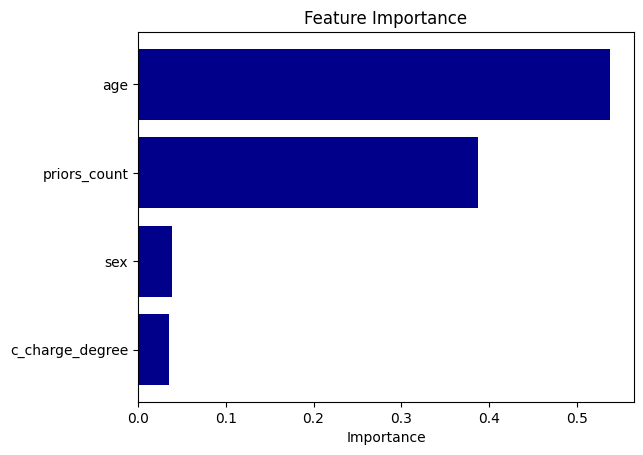

In [1215]:
names = ['Age','Sex','#Priors','Charge degree']
importance = forest.feature_importances_

plt.barh(X.columns[np.argsort(importance)], importance[np.argsort(importance)], color='darkblue')
#plt.yticks(np.arange(len(names)), labels=names)
plt.xlabel('Importance')
plt.title('Feature Importance')

According to our feature importance plot, the model relies the most on the age of the defendant as well as the number of prior charges. The model cares less about their sex and the degree of the charge.

Although the model does not take ethnicity as a variable in its training, we can consider whether prior charges and charge degree can act as proxies for ethnicity through the reality of racial profiling and harsher sentencing for certain ethnicities. If we imagine that count of prior charges is in fact the second best variable to predict recidivism, we are in trouble because the count of charges in our data might be racially biased, and therefore, the 'best' model automatically becomes unjust if we do not actively counter-act the racial bias. This is, however, not a trivial task.

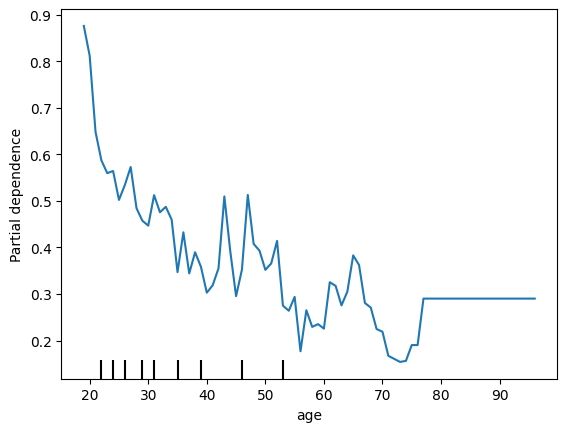

In [1216]:
from sklearn.inspection import PartialDependenceDisplay

PartialDependenceDisplay.from_estimator(forest, x_test_df, features=['age'])

The model suggests that there is a much higher chance of recidivism at younger ages. With a little bit of a cheeky increase as we go to ages beyond 80 years.